<a href="https://colab.research.google.com/github/SauSauN/Data_Nelly_Academic_Project/blob/main/Challenge_S%C3%A9v%C3%A9rit%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Objectif du projet

L'objectif de ce projet est de développer un modèle de machine learning capable of predire la sévérité des allergies chez un patient à partir de ses données cliniques et de son profil immunologique (IgE).

Ce travail s’inscrit dans une démarche d’aide à la décision médicale, visant à :

- identifier les patients à risque de formes sévères,
- mieux comprendre les facteurs associés à cette sévérité,
- exploiter des données complexes (biologiques et cliniques) à l’aide de méthodes d’intelligence artificielle.


### 2. Problématique

Le dataset ne contenent pas de variable directement associée à la sévérité des allergies. Il est donc nécessaire de répondre à la problématique suivante :

Comment construire un indicateur de sévérité pertinent à partir de variables cliniques disponibles, et dans quelle mesure les profils IgE permettent-ils de prédire cette sévérité ?

Cette problématique se décline en trois axes :

- 1. Construction d’une variable cible (sévérité) à partir d’indicateurs cliniques,
- 2. Réduction et exploitation des données biologiques (IgE) fortement dimensionnelles,
- 3. Modélisation et évaluation de la capacité prédictive des variables disponibles.


### 3. Description du dataset

Le dataset utilisé est issuing du projet Allergen Chip Challenge (ACC) et contient :

- **4 271 patients**
- **256 variables**

Chaque ligne correspond à un patient, et chaque colonne représente une caractéristique clinique ou biologique.

#### 3.1 Structure des données

Le dataset est composé de 3 grandes catégories de variables :

1.  Variables cliniques et démographiques (~15 variables)

Ces variables décrivent le contexte médical et environnemental du patient :

- Age : âge du patient
- Gender : sexe
- French_Region : région de résidence
- Rural_or_urban_area : type d’environnement
- Chip_Type : type de test biologique utilisé
- Blood_Month_sample : mois du prélèvement

2. Variables cliniques liées aux allergies :

- Treatment_of_athsma
- Treatment_of_rhinitis
- Skin_Symptoms
- General_cofactors
- Treatment_of_atopic_dematitis
- Sensitization

Ces variables permettent de caractériser :

- l’état clinique du patient,
- l’intensité de la prise en charge médicale,
- aggravated facteurs.

3. Variables biologiques (241 variables IgE)

Ces variables représentent les niveaux d’anticorps IgE spécifiques à différents allergènes.

Chaque colonne correspond à un allergène précis, suivant la nomenclature internationale (ex : **Ara_h_2**, **Der_p_1**, **Bet_v_1**).

Les allergènes sont regroupés en grandes familles :

**pollens**,
**acariens**,
**animaux**,
**aliments**,
**moisissures**,
**venins**.

Une valeur élevée indique une sensibilisation à l’allergène concerné.

#### 3.2 Spécificités et contraintes du dataset

Le dataset présente plusieurs caractéristiques importantes :

- Forte dimensionnalité (241 variables biologiques),
- Données manquantes (~30% sur certaines variables cliniques),
- Variables hétérogènes (numériques, catégorielles, binaires),
- Différents systèmes de mesure (via Chip_Type),
- Absence de variable cible directe (sévérité à construire).

Ces contraintes justifient :

- une phase de prétraitement rigoureuse,
- une réduction de dimension (PCA),
- et une construction réfléchie de la variable cible.


### 4. EDA (analyse exploratoire des données)


In [86]:
import pandas as pd

df = pd.read_csv("/content/allergenchipchallenge-data-corrected-final-hdh-sfa.csv", sep=";", encoding="utf-8", low_memory=False)
df.head()

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,...,Man_i,Mel_g,Mes_a_1_RUO,Mor_r,Mus_a,Myt_e,Ole_e_7_RUO,Ori_v,Ory_c_1,Ory_c_2
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Connaitres les types par colonnes


In [87]:
#les types de données par colonne
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Columns: 256 entries, Patient_ID to Ory_c_2
dtypes: float64(3), int64(3), object(250)
memory usage: 8.3+ MB


In [88]:
#connaitre les colonnes en flottant
float_cols = df.select_dtypes(include=['float']).columns
print("Colonnes en flottant :")
print(float_cols)

Colonnes en flottant :
Index(['Age', 'Gender', 'Blood_Month_sample'], dtype='object')


In [89]:
#connaitre les columns en integer
int_cols = df.select_dtypes(include=['int']).columns
print("Columns in integer :")
print(int_cols)

Columns in integer :
Index(['Rural_or_urban_area', 'Sensitization', 'Skin_Symptoms'], dtype='object')


In [90]:
#connaitres les colonnes en object
object_cols = df.select_dtypes(include=['object']).columns
print("Columns in object :")
print(object_cols)

Columns in object :
Index(['Patient_ID', 'Chip_Type', 'French_Residence_Department',
       'French_Region', 'Treatment_of_rhinitis', 'Treatment_of_athsma',
       'Age_of_onsets', 'General_cofactors', 'Treatment_of_atopic_dematitis',
       'Act_d_1',
       ...
       'Man_i', 'Mel_g', 'Mes_a_1_RUO', 'Mor_r', 'Mus_a', 'Myt_e',
       'Ole_e_7_RUO', 'Ori_v', 'Ory_c_1', 'Ory_c_2'],
      dtype='object', length=250)


#### Analyse des valeurs manquantes et doublons


In [91]:
#Analyse des doublons dans toute la dataframe
duplicates = df.duplicated().sum()
print("Nombre de doublons dans la DataFrame :")
print(duplicates)

Nombre de doublons dans la DataFrame :
0


In [92]:
#voir les données age qui sont vide
print(df['Age'].isnull().sum())

61


In [93]:
#nombre  de valeurs manquantes des columns float
float_missing = df[float_cols].isnull().sum()
print("Nombre de valeurs manquantes pour les colonnes float :")
print(float_missing)

Nombre de valeurs manquantes pour les colonnes float :
Age                    61
Gender                 62
Blood_Month_sample    125
dtype: int64


In [94]:
# nombre de valeurs manquantes des columns integerr
int_missing = df[int_cols].isnull().sum()
print("Number of valeurs manquantes pour les colonnes integer :")
print(int_missing)

Number of valeurs manquantes pour les colonnes integer :
Rural_or_urban_area    0
Sensitization          0
Skin_Symptoms          0
dtype: int64


In [95]:
#pourcentage de valeurs manquantes des columns object par ordre decroissant
object_missing = df[object_cols].isnull().sum()
object_missing = object_missing.sort_values(ascending=False)
object_missing = object_missing / len(df) * 100
print("Percentage of missing values for the object columns :")
print(object_missing)

Percentage of missing values for the object columns :
Alpha-Gal       81.713884
Hev_b_6         81.713884
Mel_g           73.331772
Man_i           73.331772
Mala_s_6        73.331772
                  ...    
Can_f_3          0.000000
Cla_h_8          0.000000
Cor_a_1.0401     0.000000
Cor_a_8          0.000000
Cor_a_9          0.000000
Length: 250, dtype: float64


In [96]:
#Pourcentage de colonnes avec le nombre de valeurs manquantes supérieur à 0
missing_columns = object_missing[object_missing > 0]
print("Pourcentage de colonnes avec des valeurs manquantes :")
print(missing_columns)

Pourcentage de colonnes avec des valeurs manquantes :
Alpha-Gal    81.713884
Hev_b_6      81.713884
Mel_g        73.331772
Man_i        73.331772
Mala_s_6     73.331772
               ...    
Jug_r_2      18.286116
Pol_d_5      18.286116
Ves_v_5      18.286116
Api_m_1      18.286116
Pla_a_2      18.286116
Length: 150, dtype: float64


#### Décision pour les valeurs manquante

Les variables présentant plus de **50%** de valeurs manquantes vont être supprimées, afin de garantir la qualité des données et d’éviter une imputation excessive susceptible de dégrader les performances du modèle.


In [97]:
missing_ratio = df.isnull().mean() * 100
missing_ratio = missing_ratio.sort_values(ascending=False)
print("Ratio de valeurs manquantes pour chaque colonne :")
print(missing_ratio)

Ratio de valeurs manquantes pour chaque colonne :
Alpha-Gal       81.713884
Hev_b_6         81.713884
Cup_s           73.331772
Cyn_d           73.331772
Ory_c_2         73.331772
                  ...    
Can_f_3          0.000000
Cla_h_8          0.000000
Cor_a_1.0401     0.000000
Cor_a_8          0.000000
Cor_a_9          0.000000
Length: 256, dtype: float64


In [98]:
#filtrage des colonnes avec plus de 50% de valeurs manquantes et avoir une df avec les colonnes restantes
columns_to_drop = missing_ratio[missing_ratio > 50].index
print("Colonnes à supprimer (plus de 50% de valeurs manquantes) :")
print(columns_to_drop)
df = df.drop(columns=columns_to_drop)
print("DataFrame filtered :")
df

Colonnes à supprimer (plus de 50% de valeurs manquantes) :
Index(['Alpha-Gal', 'Hev_b_6', 'Cup_s', 'Cyn_d', 'Ory_c_2', 'Ory_c_1',
       'Cyp_c_1', 'Dau_c', 'Mel_g', 'Man_i',
       ...
       'All_s', 'Aca_s', 'Aca_m', 'Hev_b_6.02', 'Hev_b_11', 'Cor_a_14',
       'Can_f_6', 'Can_f_4', 'Der_p_23', 'Ana_o_3'],
      dtype='object', length=129)
DataFrame filtered :


,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,...,Pla_l_1,Pol_d_5,Pru_p_1,Pru_p_3,Sal_k_1,Ses_i_1,Tri_a_14,Tri_a_19.0101,Tri_a_aA_TI,Ves_v_5
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9,...,0,0,0,0,0,0,0,0,0,0
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9,...,0,0,"6,69",0,0,0,0,0,0,0
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2,...,0,0,0,0,0,0,0,0,0,0
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9,...,0,0,"4,98",0,0,0,0,0,0,0
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,XPW0509,ISAC_V1,45.0,0.0,6.0,deptA,regionA,9,1,9,...,0,0,0,0,0,0,0,0,0,0
4267,XPW0510,ISAC_V1,44.0,0.0,6.0,deptA,regionA,9,1,9,...,0,"1,82","0,44",0,0,0,0,0,0,0
4268,XPW0511,ISAC_V1,23.0,1.0,6.0,deptA,regionA,9,1,9,...,0,0,0,0,0,0,0,0,0,0
4269,XPW0512,ISAC_V1,29.0,0.0,6.0,deptA,regionA,9,1,9,...,0,0,"17,66",0,0,0,0,0,0,0


In [99]:
#vérification des pourcentages de valeurs manquantes après le filtrage
df.isnull().mean().sort_values(ascending=False).head(25)

,0
Api_m_4,0.449543
Hev_b_6.01,0.449543
Act_d_8,0.266682
Bla_g_7,0.266682
Bos_d_Lactoferrin,0.266682
Cor_a_1.0101,0.266682
Can_f_5,0.266682
MUXF3,0.266682
Ole_e_7,0.266682
Phl_p_11,0.266682


#### Convertion des variables object aux bon types


In [100]:
#convertion de certaines variables object en float et garder les colonnes catégorielles dans une liste pour ne pas les convertir en float
object_cols
cols_categorical = [
    "Patient_ID",
    "Chip_Type",
    "French_Residence_Department",
    "French_Region"
]
object_cols = df.select_dtypes(include=["object"]).columns

cols_to_convert = [col for col in object_cols if col not in cols_categorical]

df[cols_to_convert] = df[cols_to_convert].apply(lambda x: x.str.replace(",", ".", regex=False))

df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors="coerce")

#### Analyse et test de normalité


Shapiro-Wilk Test Statistic: 0.8899984871198714
Shapiro-Wilk Test p-value: 9.782868554689365e-48
La variable age ne suit pas une distribution normale. Donc l'empuage de la mediane est plus approprié que la moyenne pour les données de l'age.


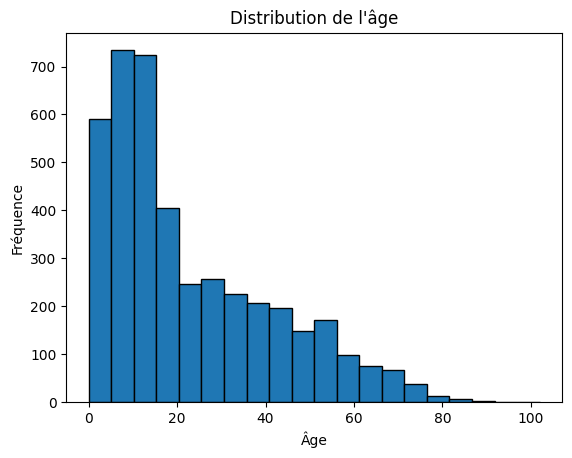

In [101]:
# Test de normalité de la variable age
from scipy import stats
age_data = df["Age"].dropna()
statistic, p_value = stats.shapiro(age_data)
print("Shapiro-Wilk Test Statistic:", statistic)
print("Shapiro-Wilk Test p-value:", p_value)
if p_value > 0.05:
    print("La variable age suit une distribution normale.")
else:
    print("La variable age ne suit pas une distribution normale. Donc l'empuage de la mediane est plus approprié que la moyenne pour les données de l'age.")

#representation graphique de la distribution de l'age
import matplotlib.pyplot as plt
plt.hist(age_data, bins=20, edgecolor='black')
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()

Shapiro-Wilk Test for General_cofactors - Statistic: 0.566429451567342, p-value: 3.363274852236774e-73
General_cofactors ne suit pas une normal distribution. Donc l'empage de la mediane est plus approprié que la moyenne pour les données de General_cofactors.
Shapiro-Wilk Test for Treatment_of_atopic_dematitis - Statistic: 0.6340294982836593, p-value: 6.037937080725063e-70
Treatment_of_atopic_dematitis ne suit pas une normal distribution. Donc l'empage de la mediane est plus approprié que la moyenne pour les données de Treatment_of_atopic_dematitis.
Shapiro-Wilk Test for Treatment_of_athsma - Statistic: 0.6511930694880355, p-value: 5.192163577313598e-69
Treatment_of_athsma ne suit pas une normal distribution. Donc l'empage de la mediane est plus approprié que la moyenne pour les données de Treatment_of_athsma.
Shapiro-Wilk Test for Age_of_onsets - Statistic: 0.7098798915752362, p-value: 2.120203585449931e-65
Age_of_onsets ne suit pas une normal distribution. Donc l'empage de la mediane 

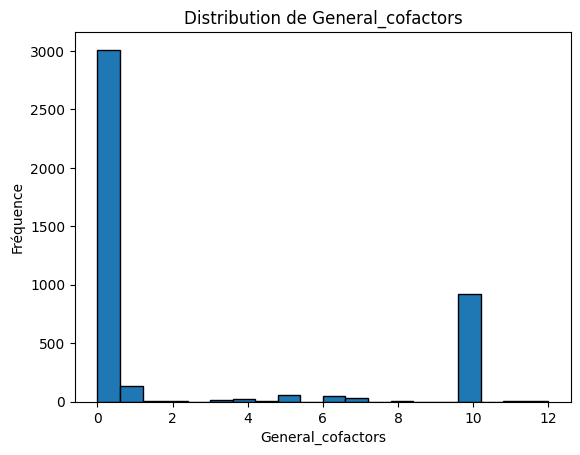

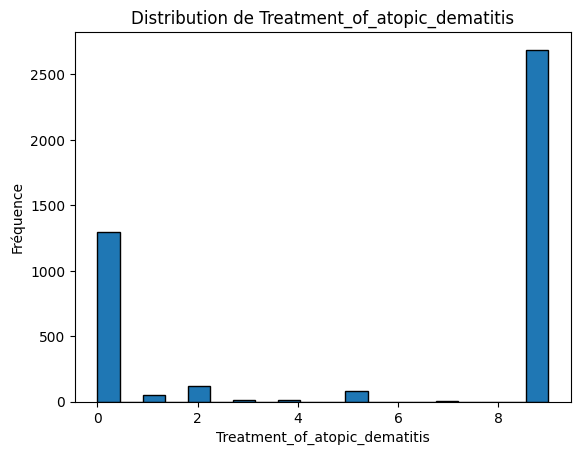

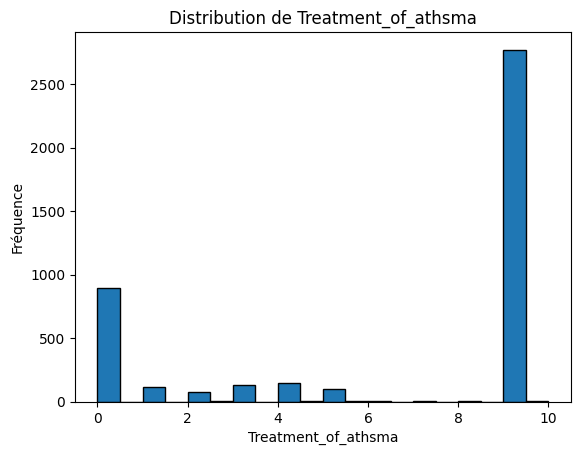

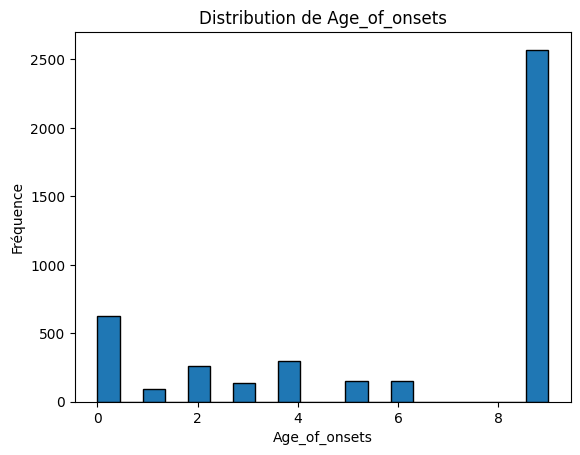

In [102]:
#Test de normalité  pour les variables General_cofactors, Treatment_of_atopic_dematitis, Treatment_of_atopic_dematitis,Treatment_of_athsma
variables_to_test = [
    "General_cofactors",
    "Treatment_of_atopic_dematitis",
    "Treatment_of_athsma",
    "Age_of_onsets"
]
for var in variables_to_test:
    data = df[var].dropna()
    stat, p = stats.shapiro(data)
    print(f"Shapiro-Wilk Test for {var} - Statistic: {stat}, p-value: {p}")
    if p > 0.05:
        print(f"{var} suit une distribution normale.")
    else:
        print(f"{var} ne suit pas une normal distribution. Donc l'empage de la mediane est plus approprié que la moyenne pour les données de {var}.")

# graphical representation of the distribution of General_cofactors, Treatment_of_atopic_dematitis, Treatment_of_athsma
for var in variables_to_test:
    data = df[var].dropna()
    plt.hist(data, bins=20, edgecolor='black')
    plt.title(f"Distribution de {var}")
    plt.xlabel(var)
    plt.ylabel("Fréquence")
    plt.show()

Shapiro-Wilk Test Statistic: 0.24745871805692332
Shapiro-Wilk Test p-value: 3.177270872946946e-85
La variable Ara_h_2 ne suit pas une normal distribution.


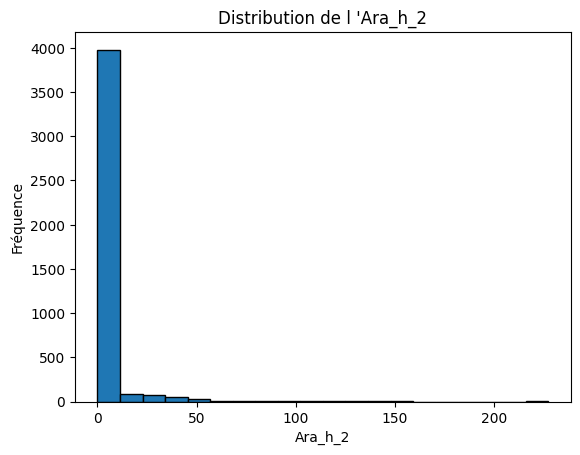

In [103]:
#### Analyse et test de normaliténtestesting
allergen_data = df["Ara_h_2"].dropna()
statistic, p_value = stats.shapiro(allergen_data)
print("Shapiro-Wilk Test Statistic:", statistic)
print("Shapiro-Wilk Test p-value:", p_value)
if p_value > 0.05:
    print("The variable Ara_h_2 suit une normal distribution.")
else:    print("La variable Ara_h_2 ne suit pas une normal distribution.")

#representation graphique de la distribution de l 'Ara_h_2
plt.hist(allergen_data, bins=20, edgecolor='black')
plt.title("Distribution de l 'Ara_h_2")
plt.xlabel("Ara_h_2")
plt.ylabel("Fréquence")
plt.show()


The variables IgE, telles that Ara_h_2, présententent des distributions fortement asymétriques et ne suivent pas une loi normale. Par conséquent, les méthodes classiques d 'imputation comme la moyenne ou la médiane ne sont pas adaptées.

De plus, dans ce contexte, les valeurs manquantes ne correspondent pas à des données manquantes aléatoires, mais plutôt à une absence de détection ou de mesure de l’allergène. Ainsi, ces valeurs ont été remplacées par 0, ce qui traduit une absence de sensibilisation.

Cette approche est cohérente avec l’interprétation biologique des données et permet de préserver la signification clinique des variables.


In [104]:
#imputation des valeurs manquantes par 0 pour les colonnes allergènes qui peut être fait avant le splitting des données
ige_cols = df.columns[15:]
df[ige_cols] = df[ige_cols].fillna(0)
df[ige_cols].isnull().sum().sum()

np.int64(0)

In [105]:
#pourcentage des valeurs manquantes par colonne
missing_percentage = df.isnull().mean() * 100
ordered_missing_percentage = missing_percentage.sort_values(ascending=False)
print("Pourcentage de valeurs manquantes par colonne :")
print(ordered_missing_percentage.head(10))


Pourcentage de valeurs manquantes par colonne :
Blood_Month_sample               2.926715
Gender                           1.451651
Age                              1.428237
General_cofactors                1.006790
Treatment_of_atopic_dematitis    0.187310
Treatment_of_athsma              0.070241
Age_of_onsets                    0.023414
French_Region                    0.000000
French_Residence_Department      0.000000
Patient_ID                       0.000000
dtype: float64


In [106]:
df

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,...,Pla_l_1,Pol_d_5,Pru_p_1,Pru_p_3,Sal_k_1,Ses_i_1,Tri_a_14,Tri_a_19.0101,Tri_a_aA_TI,Ves_v_5
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9.0,...,0.0,0.00,6.69,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9.0,...,0.0,0.00,4.98,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,XPW0509,ISAC_V1,45.0,0.0,6.0,deptA,regionA,9,1,9.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4267,XPW0510,ISAC_V1,44.0,0.0,6.0,deptA,regionA,9,1,9.0,...,0.0,1.82,0.44,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4268,XPW0511,ISAC_V1,23.0,1.0,6.0,deptA,regionA,9,1,9.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4269,XPW0512,ISAC_V1,29.0,0.0,6.0,deptA,regionA,9,1,9.0,...,0.0,0.00,17.66,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [107]:
df["Treatment_of_athsma"].value_counts()

,count
Treatment_of_athsma,
9.0,2771
0.0,897
4.0,144
3.0,128
1.0,111
5.0,101
2.0,78
6.0,8
7.0,7


In [108]:
df["Treatment_of_rhinitis"].value_counts()

,count
Treatment_of_rhinitis,
9.0,2958
0.0,883
2.0,222
3.0,106
1.0,85
4.0,9
1.3,6
2.3,1
1.2,1


In [109]:
#Pour l'instant cette variables est candidate
df["General_cofactors"].value_counts()

,count
General_cofactors,
0.0,3010
10.0,918
1.0,129
5.0,53
6.0,44
7.0,27
4.0,22
3.0,11
2.0,4


In [110]:
df["Treatment_of_atopic_dematitis"].value_counts()

,count
Treatment_of_atopic_dematitis,
9.0,2689
0.0,1294
2.0,122
5.0,84
1.0,53
4.0,11
3.0,9
7.0,1


#### Construction de la target (severity)


In [111]:
# Nettoyage préalable
df["Treatment_of_athsma"] = df["Treatment_of_athsma"].replace(9, 0)
df["Treatment_of_rhinitis"] = df["Treatment_of_rhinitis"].replace(9, 0)

# Binarisation
score_asthma = (df["Treatment_of_athsma"] > 0).astype(int)
score_rhinitis = (df["Treatment_of_rhinitis"] > 0).astype(int)
score_cofactor = (df["General_cofactors"] > 0).astype(int)

# Score pondéré
df["severity_score"] = (2 * score_cofactor + score_asthma + score_rhinitis)

# Target au moins 2 signaux OU 1 signal fort
df["severity"] = (df["severity_score"] >= 2).astype(int)

/tmp/ipykernel_1423/3156011233.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["severity_score"] = (2 * score_cofactor + score_asthma + score_rhinitis)
/tmp/ipykernel_1423/3156011233.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["severity"] = (df["severity_score"] >= 2).astype(int)


In [112]:
score_rhinitis.value_counts()

,count
Treatment_of_rhinitis,
0,3841
1,430


In [113]:
df["severity_score"].value_counts()

,count
severity_score,
0,2460
2,1274
1,380
3,90
4,67


In [114]:
df["severity"].value_counts()

,count
severity,
0,2840
1,1431


Les pondérations ont été définies à partir de la distribution des variables. Les cofacteurs présentent une forte capacité discriminante (valeurs élevées concentrées sur une minorité de patients), justifiant une pondération plus élevée. Les traitements de l’asthme et de la rhinite, plus fréquents et moins discriminants, ont été pondérés de manière équivalente et plus faible car la pluspart des valeurs sont de 9=non renseigner qui ont été remplacer par 0 et ces deux variables ont une ppondération faible


In [115]:
df

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,...,Pru_p_1,Pru_p_3,Sal_k_1,Ses_i_1,Tri_a_14,Tri_a_19.0101,Tri_a_aA_TI,Ves_v_5,severity_score,severity
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,0.0,...,6.69,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,1
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,0.0,...,4.98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,XPW0509,ISAC_V1,45.0,0.0,6.0,deptA,regionA,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4267,XPW0510,ISAC_V1,44.0,0.0,6.0,deptA,regionA,9,1,0.0,...,0.44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4268,XPW0511,ISAC_V1,23.0,1.0,6.0,deptA,regionA,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4269,XPW0512,ISAC_V1,29.0,0.0,6.0,deptA,regionA,9,1,0.0,...,17.66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [116]:
#taux de valeurs manquantes pour chaque colonne
missing_ratio = df.isnull().mean() * 100
missing_ratio = missing_ratio.sort_values(ascending=False)
print("Ratio de valeurs manquantes pour chaque colonne :")
print(missing_ratio.head(20))

Ratio de valeurs manquantes pour chaque colonne :
Blood_Month_sample               2.926715
Gender                           1.451651
Age                              1.428237
General_cofactors                1.006790
Treatment_of_atopic_dematitis    0.187310
Treatment_of_athsma              0.070241
Age_of_onsets                    0.023414
Patient_ID                       0.000000
Chip_Type                        0.000000
Sensitization                    0.000000
Rural_or_urban_area              0.000000
French_Region                    0.000000
French_Residence_Department      0.000000
Skin_Symptoms                    0.000000
Treatment_of_rhinitis            0.000000
Act_d_1                          0.000000
Act_d_2                          0.000000
Act_d_5                          0.000000
Act_d_8                          0.000000
Aln_g_1                          0.000000
dtype: float64


### Split des données en trainning et testing


# faire le split de donnée ici pour lev données d'entrainement avant l'imputation des NAN

### Imputation des valeurs manquantes


In [117]:
#imputation des valeurs manquantes par la médiane pour les variables General_cofactors, Treatment_of_atopic_dematitis, Treatment_of_atopic_dematitis,Treatment_of_athsma
variables_to_impute = [
    "General_cofactors",
    "Treatment_of_atopic_dematitis",
    "Treatment_of_athsma",
    "Age_of_onsets"
]
for var in variables_to_impute:
    median_value = df[var].median()
    df[var] = df[var].fillna(median_value)

In [118]:
# imputation des valeurs manquantes pour les colonnes Age et Gender et Blood_Month_sample
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Blood_Month_sample"] = df["Blood_Month_sample"].fillna(df["Blood_Month_sample"].mode()[0])

In [119]:
#conversion of certain float columns to integer
df['Age'] = df['Age'].astype(int)
df['Gender'] = df['Gender'].astype(int)
df["Blood_Month_sample"] = df["Blood_Month_sample"].astype(int)
df.head()

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,...,Pru_p_1,Pru_p_3,Sal_k_1,Ses_i_1,Tri_a_14,Tri_a_19.0101,Tri_a_aA_TI,Ves_v_5,severity_score,severity
0,FHB0001,ISAC_V1,21,1,11,deptY,regionB,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,FHB0002,ISAC_V1,45,0,12,deptY,regionB,9,1,0.0,...,6.69,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,FHB0003,ISAC_V1,18,1,1,deptY,regionB,9,0,2.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,1
3,FHB0004,ISAC_V1,19,0,1,deptY,regionB,9,1,0.0,...,4.98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,FHB0005,ISAC_V1,28,0,1,deptY,regionB,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


#### Vérification des types de variables après conversion


In [120]:
#liste des vairables catégorielles après convertion
object_cols = df.select_dtypes(include=["object"]).columns
print("Colonnes catégorielles :")
print(object_cols)

Colonnes catégorielles :
Index(['Patient_ID', 'Chip_Type', 'French_Residence_Department',
       'French_Region'],
      dtype='object')


In [121]:
#liste des variables float après conversion
float_cols = df.select_dtypes(include=["float"]).columns
print("Columns en float après conversion :")
print(float_cols)

Columns en float après conversion :
Index(['Treatment_of_rhinitis', 'Treatment_of_athsma', 'Age_of_onsets',
       'General_cofactors', 'Treatment_of_atopic_dematitis', 'Act_d_1',
       'Act_d_2', 'Act_d_5', 'Act_d_8', 'Aln_g_1',
       ...
       'Pla_l_1', 'Pol_d_5', 'Pru_p_1', 'Pru_p_3', 'Sal_k_1', 'Ses_i_1',
       'Tri_a_14', 'Tri_a_19.0101', 'Tri_a_aA_TI', 'Ves_v_5'],
      dtype='object', length=117)


In [122]:
#liste  des variables int après conversion
int_cols = df.select_dtypes(include=["int"]).columns
print("Columns en int après conversion :")
print(int_cols)

Columns en int après conversion :
Index(['Age', 'Gender', 'Blood_Month_sample', 'Rural_or_urban_area',
       'Sensitization', 'Skin_Symptoms', 'severity_score', 'severity'],
      dtype='object')


In [123]:
#liste de colonnes dans une liste
columns_list = df.columns.tolist()
print(columns_list)

['Patient_ID', 'Chip_Type', 'Age', 'Gender', 'Blood_Month_sample', 'French_Residence_Department', 'French_Region', 'Rural_or_urban_area', 'Sensitization', 'Treatment_of_rhinitis', 'Treatment_of_athsma', 'Age_of_onsets', 'Skin_Symptoms', 'General_cofactors', 'Treatment_of_atopic_dematitis', 'Act_d_1', 'Act_d_2', 'Act_d_5', 'Act_d_8', 'Aln_g_1', 'Alt_a_1', 'Alt_a_6', 'Amb_a_1', 'Ana_o_2', 'Ani_s_1', 'Ani_s_3', 'Api_g_1', 'Api_m_1', 'Api_m_4', 'Ara_h_1', 'Ara_h_2', 'Ara_h_3', 'Ara_h_6', 'Ara_h_8', 'Ara_h_9', 'Art_v_1', 'Art_v_3', 'Asp_f_1', 'Asp_f_3', 'Asp_f_6', 'Ber_e_1', 'Bet_v_1', 'Bet_v_2', 'Bet_v_4', 'Bla_g_1', 'Bla_g_2', 'Bla_g_5', 'Bla_g_7', 'Blo_t_5', 'Bos_d_4', 'Bos_d_5', 'Bos_d_6', 'Bos_d_8', 'Bos_d_Lactoferrin', 'Can_f_1', 'Can_f_2', 'Can_f_3', 'Can_f_5', 'Che_a_1', 'Cla_h_8', 'Cor_a_1.0101', 'Cor_a_1.0401', 'Cor_a_8', 'Cor_a_9', 'Cry_j_1', 'Cup_a_1', 'Cyn_d_1', 'Der_f_1', 'Der_f_2', 'Der_p_1', 'Der_p_10', 'Der_p_2', 'Equ_c_1', 'Equ_c_3', 'Fag_e_2', 'Fel_d_1', 'Fel_d_2', 'Fel_d

In [124]:
print(len(columns_list))

129


In [125]:
df

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,...,Pru_p_1,Pru_p_3,Sal_k_1,Ses_i_1,Tri_a_14,Tri_a_19.0101,Tri_a_aA_TI,Ves_v_5,severity_score,severity
0,FHB0001,ISAC_V1,21,1,11,deptY,regionB,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,FHB0002,ISAC_V1,45,0,12,deptY,regionB,9,1,0.0,...,6.69,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,FHB0003,ISAC_V1,18,1,1,deptY,regionB,9,0,2.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,1
3,FHB0004,ISAC_V1,19,0,1,deptY,regionB,9,1,0.0,...,4.98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,FHB0005,ISAC_V1,28,0,1,deptY,regionB,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,XPW0509,ISAC_V1,45,0,6,deptA,regionA,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4267,XPW0510,ISAC_V1,44,0,6,deptA,regionA,9,1,0.0,...,0.44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4268,XPW0511,ISAC_V1,23,1,6,deptA,regionA,9,1,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4269,XPW0512,ISAC_V1,29,0,6,deptA,regionA,9,1,0.0,...,17.66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [127]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor, MLPClassifier


# Définir les colonnes cibles
target_score = 'severity_score'
target_class = 'severity'

# Colonnes à utiliser comme features (tout sauf cibles)
features = []
for col in df.columns:
    if col != target_score and col != target_class:
        features.append(col)

X = df[features]
y_score = df[target_score]
y_class = df[target_class]

# Identifier les colonnes numériques et catégorielles
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

In [128]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

### MLP pour severity_score (régression)

In [131]:
mlp_reg = Pipeline([
    ('preprocess', preprocessor),
    ('mlp', MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu',
                         solver='adam', max_iter=500, random_state=42))
])

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_score, test_size=0.2, random_state=42)

# Entraînement
mlp_reg.fit(X_train, y_train)

# Performance
print("R² sur test:", mlp_reg.score(X_test, y_test))

R² sur test: 0.7720595859509748
